In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment working!")
print("scikit-learn:", sklearn.__version__)

Environment working!
scikit-learn: 1.9.0


In [ ]:
df = pd.read_excel('../data/default+of+credit+card+clients/default of credit card clients.xls', engine='xlrd', index_col=0, header=1 )
print(df.info())

In [ ]:
print(df.head())

In [18]:
print(df.shape)

(30000, 24)


In [ ]:
print(df.columns)
print(f"Length of the column: {len(df.columns)}")


In [ ]:
print(df.isna().sum())

In [ ]:
print(df.describe().T)

In [15]:
print(df['default payment next month'].value_counts())

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
print(df['SEX'].value_counts())
print(df['SEX'].value_counts(normalize=True))

In [35]:
print(df["EDUCATION"].value_counts())
print(df["EDUCATION"].value_counts(normalize=True)*100)

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
EDUCATION
2    46.766667
1    35.283333
3    16.390000
5     0.933333
4     0.410000
6     0.170000
0     0.046667
Name: proportion, dtype: float64


In [ ]:
print(df["MARRIAGE"].value_counts())
print(df["MARRIAGE"].value_counts(normalize=True)*100)

In [28]:
def_rate_by_edu= df.groupby("EDUCATION")['default payment next month'].mean().sort_values(ascending=False) * 100
print(def_rate_by_edu)

EDUCATION
3    25.157616
2    23.734854
1    19.234766
6    15.686275
5     6.428571
4     5.691057
0     0.000000
Name: default payment next month, dtype: float64


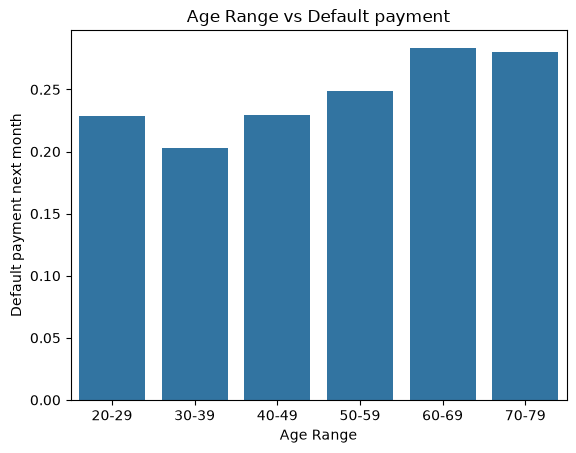

In [43]:
bins= [20, 30, 40, 50 , 60, 70 ,80]
labels= ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['age_range']= pd.cut(df["AGE"], bins=bins, labels=labels, right=False )


def_rate_by_age= df.groupby('age_range')['default payment next month'].mean().sort_values(ascending=False) * 100
#print(def_rate_by_age)

sns.barplot(data=df, 
            x='age_range',
            y='default payment next month' ,
            order=labels,
            errorbar=None )

plt.xlabel("Age Range")
plt.ylabel("Default payment next month")
plt.title("Age Range vs Default payment")

plt.show()

In [ ]:
def_rate_by_pay0= df.groupby('PAY_0')['default payment next month'].mean().sort_values(ascending=False)*100
print(def_rate_by_pay0)

PAY_0
 7    77.777778
 3    75.776398
 2    69.141357
 4    68.421053
 8    57.894737
 6    54.545455
 5    50.000000
 1    33.947939
-1    16.778051
-2    13.229431
 0    12.811291
Name: default payment next month, dtype: float64


AttributeError: QuadMesh.set() got an unexpected keyword argument 'order'

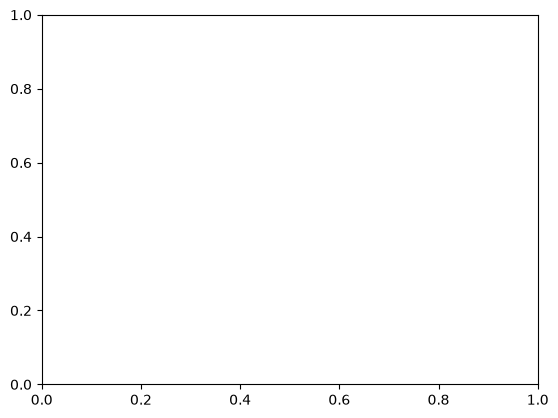

In [ ]:
sns.barplot(data=df,
            x="PAY_0", 
            y="default payment next month", 
            order=sorted(df['PAY_0']),
            errorbar=None )

plt.xlabel('PAY_0')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by PAY_0 Category')

plt.show()

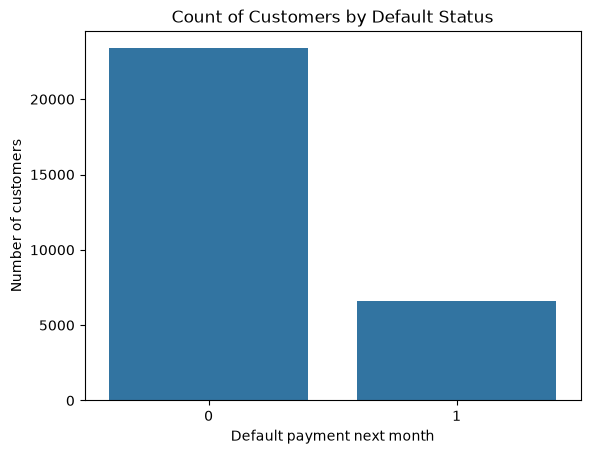

In [36]:
sns.countplot(data=df, x='default payment next month')
plt.xlabel("Default payment next month")
plt.ylabel("Number of customers")
plt.title('Count of Customers by Default Status')
plt.show()

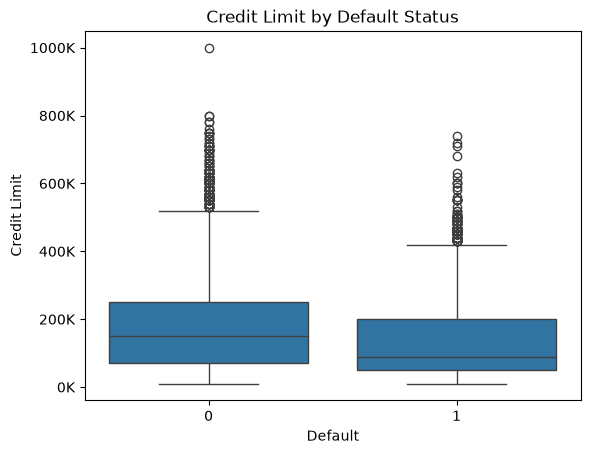

In [47]:
from matplotlib.ticker import FuncFormatter
sns.boxplot(
    data=df,
    x="default payment next month",
    y="LIMIT_BAL"
)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.title("Credit Limit by Default Status")
plt.show()

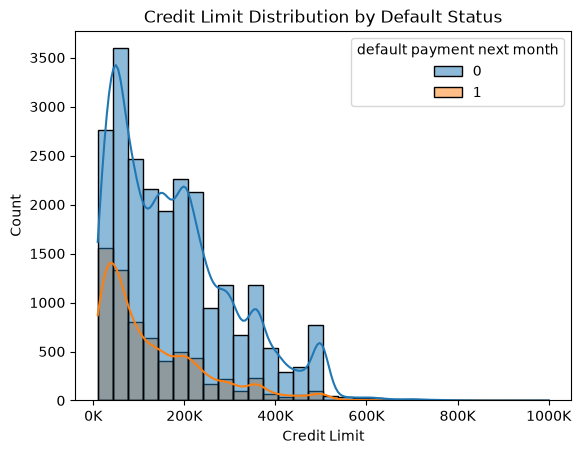

In [5]:
from matplotlib.ticker import FuncFormatter
sns.histplot(
    data=df,
    x="LIMIT_BAL",
    hue="default payment next month",
    bins=30,
    kde=True
)
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Credit Limit")
plt.title("Credit Limit Distribution by Default Status")
plt.show()

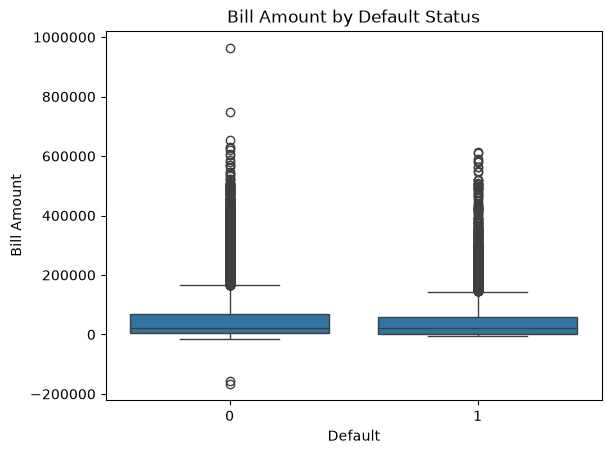

In [7]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="BILL_AMT1"
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Default")
plt.ylabel("Bill Amount")
plt.title("Bill Amount by Default Status")
plt.show()

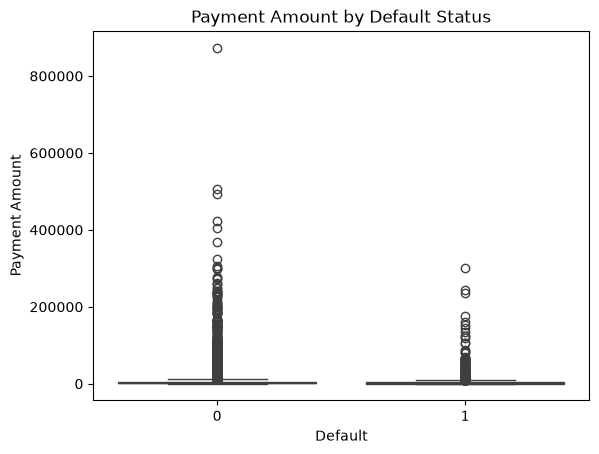

In [8]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="PAY_AMT1"
)

plt.xlabel("Default")
plt.ylabel("Payment Amount")
plt.title("Payment Amount by Default Status")
plt.show()

************************************************************************
--------------------------Correlation Analysis-------------------------
************************************************************************

In [16]:
corr= df.corr(numeric_only=True)
corr['default payment next month'].sort_values(ascending=False) * 100



default payment next month    100.000000
PAY_0                          32.479373
PAY_2                          26.355120
PAY_3                          23.525251
PAY_4                          21.661364
PAY_5                          20.414891
PAY_6                          18.686636
EDUCATION                       2.800608
AGE                             1.388983
BILL_AMT6                      -0.537231
BILL_AMT5                      -0.676046
BILL_AMT4                      -1.015650
BILL_AMT3                      -1.407552
BILL_AMT2                      -1.419322
BILL_AMT1                      -1.964420
MARRIAGE                       -2.433922
SEX                            -3.996058
PAY_AMT6                       -5.318334
PAY_AMT5                       -5.512352
PAY_AMT3                       -5.625035
PAY_AMT4                       -5.682740
PAY_AMT2                       -5.857871
PAY_AMT1                       -7.292949
LIMIT_BAL                     -15.351988
Name: default pa

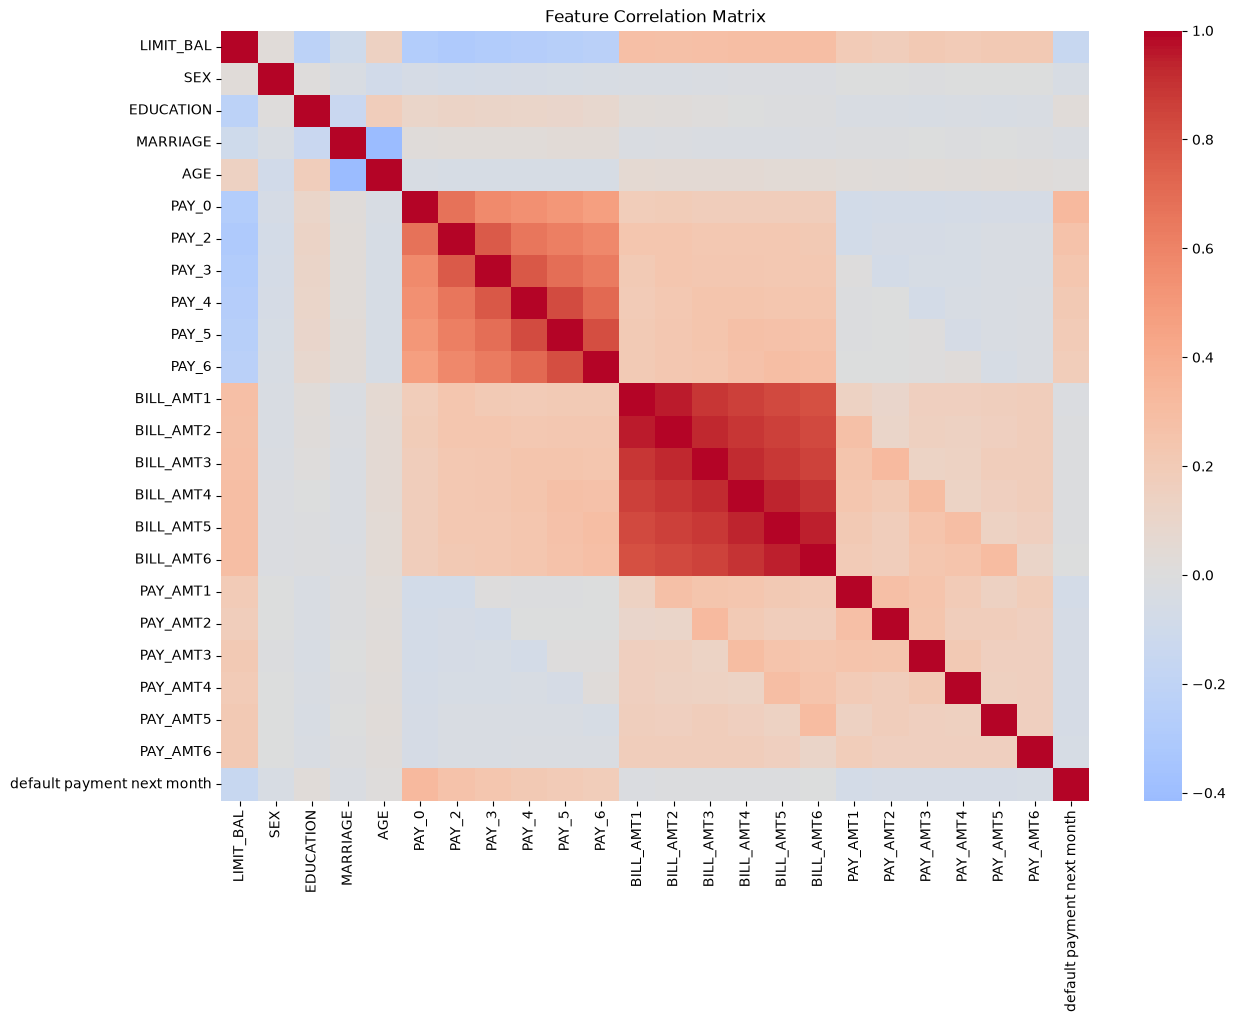

In [17]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()